# Learning Outcomes

Before going through this chapter, we expect you to be familiar with sampling techniques and quantization (Separation in bins, similar to that of histogram). You should have gone through some basics of resizing. After going through this chapter, you will learn:
1. Intuition behind interpolation
2. Linear interpolation
3. Importance of interpolation in image processing


# Interpolation

In the previous chapter, you dived into resizing, and it's relevant techniques. In this chapter, you are going to dive deeper into interpolation and understand how it works.

The main idea behind interpolation is estimating intermediate values. In the previous section, you saw the necessity of filling values when we are resizing. If we don't fill the values, then we are losing a pretty significant amount of information. Therefore we have to have some ways to fill values.

Image signals are continuous. Before any digital image is formed, we have to sample these signals and represent them in pixels. When the image is forming, the sampling depends on the sensor parameters and camera too. We won't go much into that.

Since you are going to deal with the final image, you should think of how to get these continuous image signals again. Reconstructing signal might sound complicated. Thus transformations into the frequency domain followed by the application of filters and conversion into spatial domain ease the process.

<div align="center">
<figure>
<!-- <img src="https://doc.google.com/a/fusemachines.com/uc?export=download&id=1FUWgIsynkm-81jpfUEOI4E0XaUTiKhAt" > -->
<img src=" https://i.postimg.cc/d1jtt1gT/image.png">
<figcaption>Figure 1. Interpolation
</figcaption>
</figure>
</div>

To have a more understanding of interpolation, we can see this figure 1. Here, when the original image is explanding by 3 times then we have a image with lots of spatial pixels. These pixels carry a lot of information so they need to be filled to retain the original image information. The process of finding and filling these intermediate values are referred to as image interpolation.

Most of these interpolation relies on some continuous function. Once we estimate the continuous function, we have to determine the missing value using this function. After this, we quantize these estimated values to a corresponding digital value, and finally, we obtain the newly resized image.

There are several types of interpolation techniques. In this chapter, we will discuss few of the interpolation techniques like:

1. Nearest Neighbour Interpolation
2. Linear Interpolation
3. Bilinear Interpolation
4. Bicubic Interpolation

#Nearest Neighbour Interpolation

The nearest neighbour interpolation is the simplest form of interpolation technique. In this interpolation, nearest point to the current point is selected and updated. Consider this example:

<div align="center">
<figure>
<!-- <img src="https://doc.google.com/a/fusemachines.com/uc?export=download&id=1QP2_P-9UoK2qQGqyCvaQkDG0i33E8Q21" > -->
<img src="https://i.postimg.cc/bvdBwFM0/image.png" >
<figcaption>Figure 2. Nearest Neighbour Interpolation
</figcaption>
</figure>
</div>

When figure 1 is interpolated using the nearest neighbour interpolation, we obtain figure 2. Here, in figure 2 the values are interpolated in a manner where the pixels are nearest to a current pixel. For example, if you see 10, we can see that the pixels are updated in a way that pixels close to 10 are only updated as 10 and similar goes for 20, 30 and 40.

This is simplest form of interpolation. In the following coding implementation also, we will visualize the nearest neighbour interpolation.

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10. ]


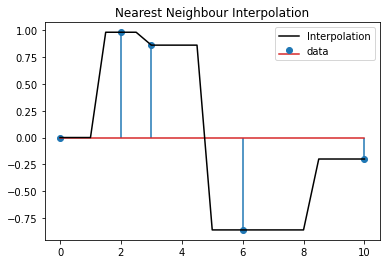

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
x = np.array([0, 2, 3, 6, 10])
y = np.array([0, 0.98, 0.86, -0.86, -0.2])
t = np.arange(0, 10.5, 0.5)
print(t)
lin_fun = interp1d(x, y, kind='nearest')
plt.stem(x, y, '-o', use_line_collection=True, label="data")
new = lin_fun(t)
plt.plot(t, lin_fun(t), "-k", label="Interpolation")
plt.title("Nearest Neighbour Interpolation")
plt.legend()
plt.show()

Here, in this implementation, we can see that the bluepoints are the original points and on the basis of this we have to draw a interpolated function. So, here we obtain a step function because the pixels close to one another will be on the same range and lie on the same line. So, if we have pixels at different lines we will obtain a step function as above.

#Linear Interpolation


Here we are going to deal with linear interpolation of 1-D function.

<div align="center">
<figure>
<!-- <img src="https://doc.google.com/a/fusemachines.com/uc?export=download&id=1r2knhivxuXgsffU2ZA5dBPxgeEPYI966" > -->
<img src="https://i.postimg.cc/4yZdGtdc/image.png" >
<figcaption>Figure 3. Linear Interpolation
</figcaption>
</figure>
</div>

In the figure 3, we want to interpolate different points between red and blue points. Unlike nearest neighbour, here interpolate points with respect to one other points. We can also see that, we interpolate between a straight line joining the initial two points.

So, let's see an example to get a clear idea about the linear interpolation.

<div align="center">
<figure>
<!-- <img src="https://doc.google.com/a/fusemachines.com/uc?export=download&id=1-zlGTPvzyR777Jxsnr30U0okY7Kk2cQh" > -->
<img src="https://i.postimg.cc/W4jfM1hn/image.png" >
<figcaption>Figure 4. Linear Interpolation on an Image
</figcaption>
</figure>
</div>

Consider this example from Figure 1. If we want to compute the interpolate the pixel value at P then how do we interpolate.

So, during linear interpolation there are several steps that need to be followed.

Here, the distance between the pixel in the orignal image is 1 and after expansion by three times the distance between the image will become 1/3 as displayed on Figure 5 too.


<div align="center">
<figure>
<!-- <img src="https://doc.google.com/a/fusemachines.com/uc?export=download&id=1sm3w2ErieagcqgO4s12c1O27utwYPAyw" > -->
<img src="https://i.postimg.cc/dtVCTPsy/image.png" >
<figcaption>Figure 5. Linear Interpolation on an Image
</figcaption>
</figure>
</div>

Now, we will perform some mathematical formulation to calculate the interpolated value of pixel P.


$P = 10 * \frac{2}{3} + 20 * \frac{1}{3}$

$P = \frac{40}{3}$

$2/3$ and $1/3$ are the distance of pixel P from 20 and 10 pixels. They act as the respective weights and on the basis of these weights, we interpolate.

With this interpolation, we obtain the value of P as $40/3$ or $13.33$ and we obtain the interpolated image as:

<div align="center">
<figure>
<!-- <img src="https://doc.google.com/a/fusemachines.com/uc?export=download&id=1EkmMqo-YiGZ1TD6eT0SrGfNHLpMqDnun" > -->
<img src="https://i.postimg.cc/NGDYLLjQ/image.png"/>
<figcaption>Figure 6. Linear Interpolation on an Image
</figcaption>
</figure>
</div>

So, in this way we perform the linear interpolation. In the following python implementation, we can also see the implementation of Linear Interpolation.

## Implementation


Let's  dive in further by looking onto the implementation details for linear interpolation. We are going to take a sin function

[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10. ]


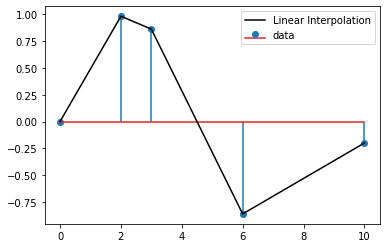

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
x = np.array([0, 2, 3, 6, 10])
y = np.array([0, 0.98, 0.86, -0.86, -0.2])
t = np.arange(0, 10.5, 0.5)
print(t)
lin_fun = interp1d(x, y, kind='linear')
plt.stem(x, y, '-o', use_line_collection=True, label="data")
new = lin_fun(t)
plt.plot(t, lin_fun(t), "-k", label="Linear Interpolation")
plt.legend()
plt.show()

Here, in this plot we can see that blue points are the initial points and a line is interpolated on the basis of this points. The points on this line are interpolated on the similar way that we performed.

#Key Takeaways

1. Interpolation samples the missing data from a continuous signal
2. In image processing, interpolation helps to fill in the missing values